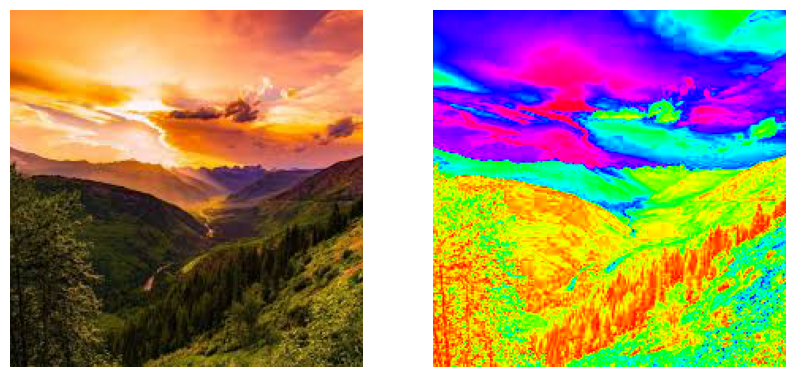

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
#fuucnoines what
def hsv_a_rgb(H, S, V):
    H = H % 360
    C = V * S
    X = C * (1 - abs((H / 60) % 2 - 1))
    m = V - C

    if 0 <= H < 60:
        Rp, Gp, Bp = C, X, 0
    elif 60 <= H < 120:
        Rp, Gp, Bp = X, C, 0
    elif 120 <= H < 180:
        Rp, Gp, Bp = 0, C, X
    elif 180 <= H < 240:
        Rp, Gp, Bp = 0, X, C
    elif 240 <= H < 300:
        Rp, Gp, Bp = X, 0, C
    else:
        Rp, Gp, Bp = C, 0, X

    R = (Rp + m) * 255
    G = (Gp + m) * 255
    B = (Bp + m) * 255

    return int(round(R)), int(round(G)), int(round(B))

img = cv2.imread('image.jpg')
if img is None:
    exit()

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

hsv_img = np.zeros((img_gray.shape[0], img_gray.shape[1], 3), dtype=np.uint8)

for i in range(img_gray.shape[0]):
    for j in range(img_gray.shape[1]):
        H = (img_gray[i, j] / 255) * 360
        S = 1
        V = 1
        hsv_img[i, j] = hsv_a_rgb(H, S, V)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(hsv_img)
plt.axis("off")

plt.show()